In [1]:
%reload_ext autoreload
%autoreload 2

import pickle
import matplotlib.pyplot as plt
import numpy as np

import sys
sys.path.append("..")

from utils.validation import plot_coverage

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colormaps as cms
mpl.rc_file("../../nptf-test/production/matplotlibrc")

In [5]:
z = pickle.load(open('../outputs/fit/hmc_gcfullAlm_gcfull_kingpsf_1004/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_psc', 'S_blg', 'S_nfw', 'gamma_poiss', 'Sps_nfw', 'gamma_ps', 'Sps_blg', 'Sps_dsk', 'zs', 'C', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'f_bulge_ps'])


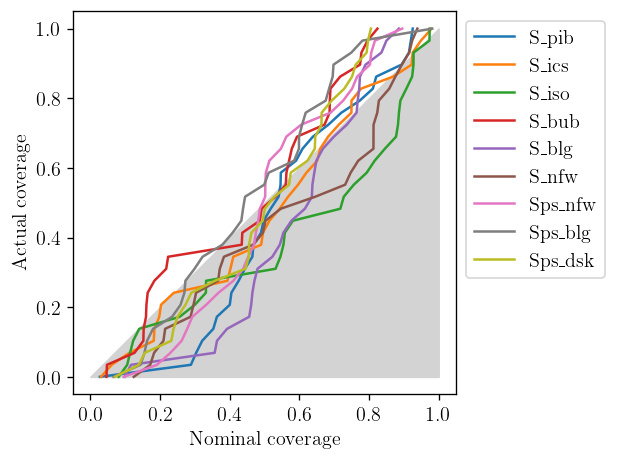

In [6]:
# labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce',
#           'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs']
# labels = ['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'Sps_dsk', 'Sps_gce']
# labels = ['Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce']
# labels = ['Sps_nfw', 'Sps_dsk', 'S_pib', 'S_ics', 'S_dsk', 'S_nfw', 'S_bub']
labels = ["S_pib", "S_ics", "S_iso", "S_bub", "S_blg", "S_nfw",
          "Sps_nfw", "Sps_blg", "Sps_dsk"]
# labels = ['Sps_nfw', 'Sps_dsk']
probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

n_run = len(probs[0])
ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

# invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
# ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
# ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1)
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage')
# ax.text(0.95, 0.05, 'overconfident', ha='right', va='center')
# ax.text(0.05, 0.95, 'underconfident', ha='left', va='center')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()
# plt.savefig('tmp.pdf')

In [4]:
from utils.multi_corner import multi_corner
import json

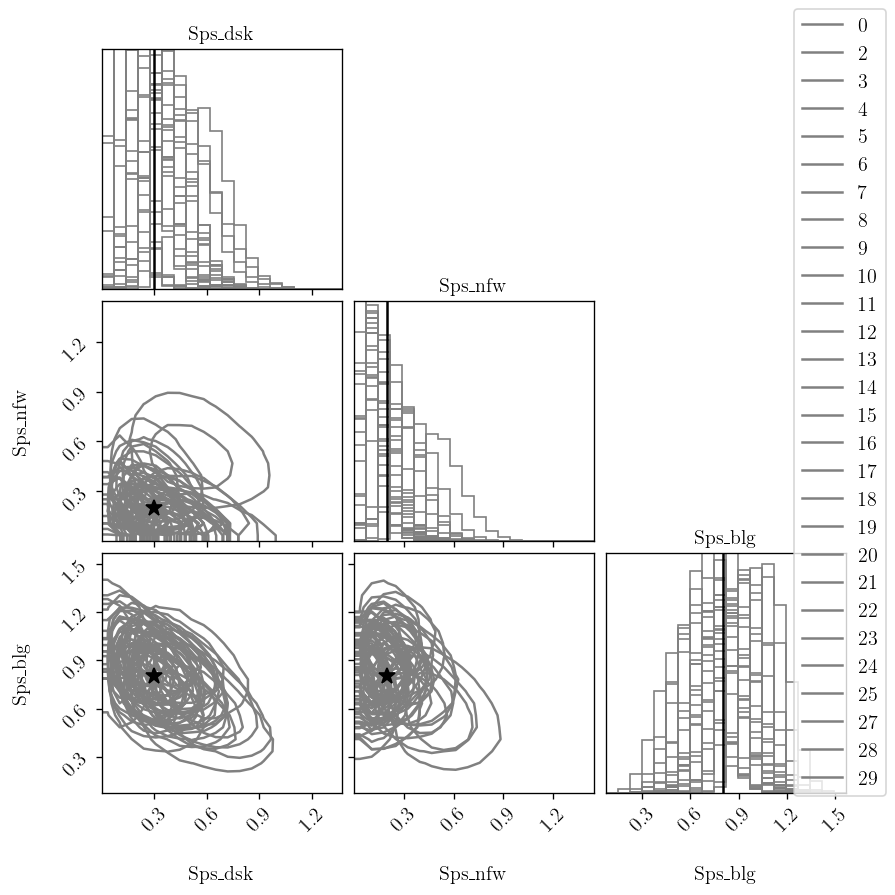

In [5]:
labels = ['Sps_dsk', 'Sps_nfw', 'Sps_blg']
s_in = {}
labels_dict = {}
colors_dict = {}
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    nskey = str(x)
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    s_in[nskey] = {k: s[k] for k in labels}
    labels_dict[nskey] = nskey
    colors_dict[nskey] = 'gray'

truth_dict = json.load(open('truth_dict_gcfull.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

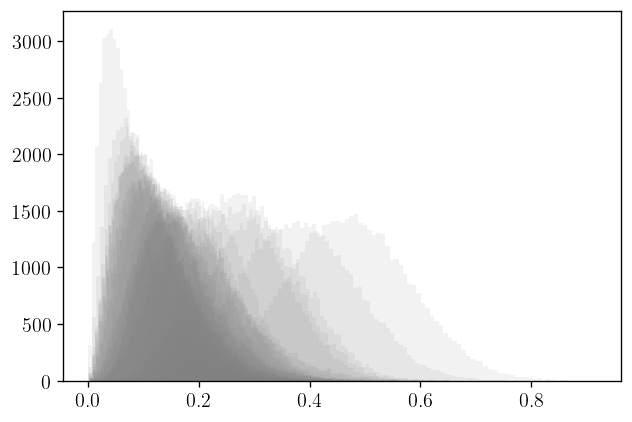

In [14]:
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    s['f_bulge_ps'] = s['Sps_nfw'] / (s['Sps_nfw'] + s['Sps_blg'])
    plt.hist(s['f_bulge_ps'], bins=100, color='gray', alpha=0.1)

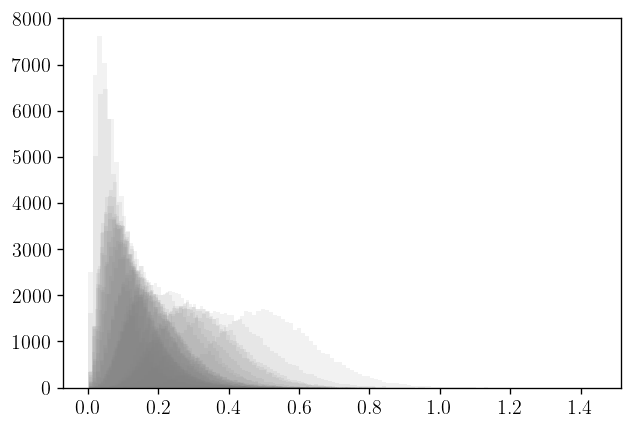

In [15]:
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    plt.hist(s['Sps_nfw'], bins=100, color='gray', alpha=0.1)

In [18]:
mean_list = []
for i, x in enumerate(range(30)):
    if x in [1, 26]:
        continue
    s = pickle.load(open(f'../outputs/fit/svi_gcfull_gcfull_deltapsf_0930/svi_samples_i{x}_n50000_ns10000.p', 'rb'))
    mean_list.append(np.mean(s['Sps_nfw']))
    print(np.mean(s['Sps_nfw']))
print()
print(np.mean(mean_list))

0.18449177
0.15595655
0.1212401
0.3180623
0.1789521
0.17978157
0.1179898
0.28864715
0.12681703
0.22198203
0.18182948
0.19924499
0.13383189
0.5159404
0.32947865
0.0707873
0.39503214
0.26024175
0.09677824
0.1291483
0.08956079
0.13855295
0.18012261
0.30754653
0.11175638
0.19180451
0.14391898
0.11125221

0.19574103


In [2]:
data = np.load("../outputs/simulations/sim_gcfull_deltapsf_n100.npy")

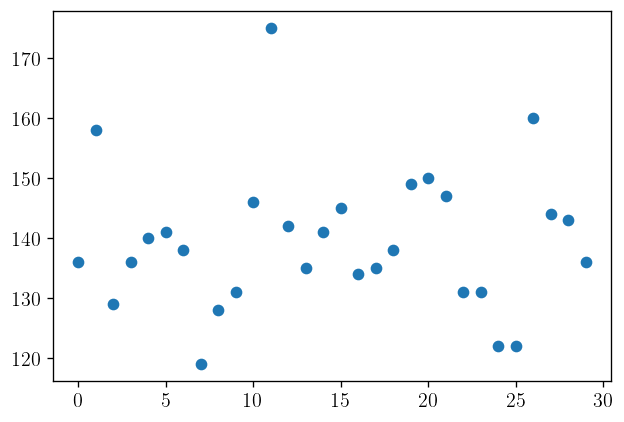

In [5]:
max_s = []
for i in range(30):
    max_s.append(np.max(data[i]))
plt.plot(max_s, 'o')

In [ ]:
labels = list(z.keys())
s_in = {}
labels_dict = {}
for i, x in enumerate([10000, 1000]):
    key = str(i)
    s = pickle.load(open(f'../outputs/fit/svi_240817_singledeltapsf/svi_samples_i0_n50000_ns{x}.p', 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = str(x)

truth_dict = json.load(open('truth_dict_flat.json', 'r'))
t_in = {k: truth_dict[k] for k in labels}

colors_dict = {
    '0' : 'C0',
    '1' : 'C1',
}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

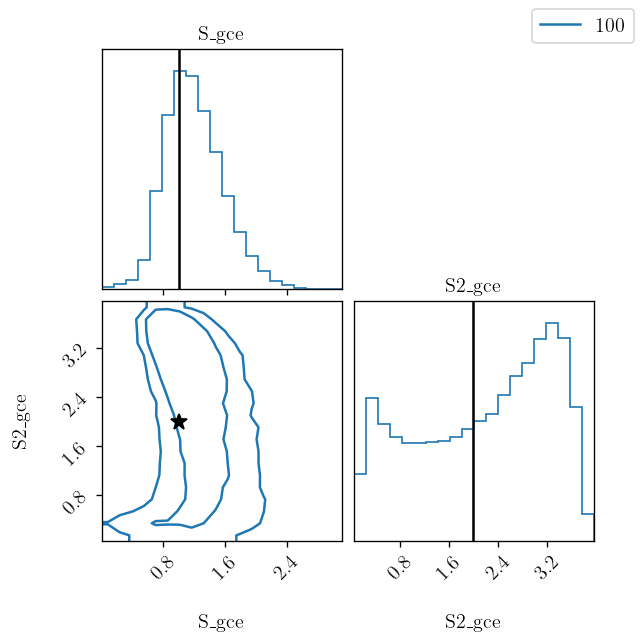

In [22]:
labels = ['S_gce', 'S2_gce']
s_in = {}
labels_dict = {}
for i, x in enumerate([100]):
    key = str(i)
    s = pickle.load(open(f'../outputs/fit/svi_240817_singledeltapsf/svi_samples_i0_n50000_ns{x}.p', 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = str(x)

truth_dict = json.load(open('truth_dict_flat.json', 'r'))
t_in = {
    'S_gce' : truth_dict['Sps_gce'],
    'S2_gce' : 2.,
}

colors_dict = {
    '0' : 'C0',
}

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)

## View data

In [6]:
import numpy as np
import healpy as hp

In [10]:
d_old = np.load("../outputs/simulations/sim_gc17old_deltapsf_n100.npy")
d_new = np.load("../outputs/simulations/sim_gc17_deltapsf_n100.npy")
mn = np.load("mask_norm.npy")
mr = np.load("mask_roi.npy")

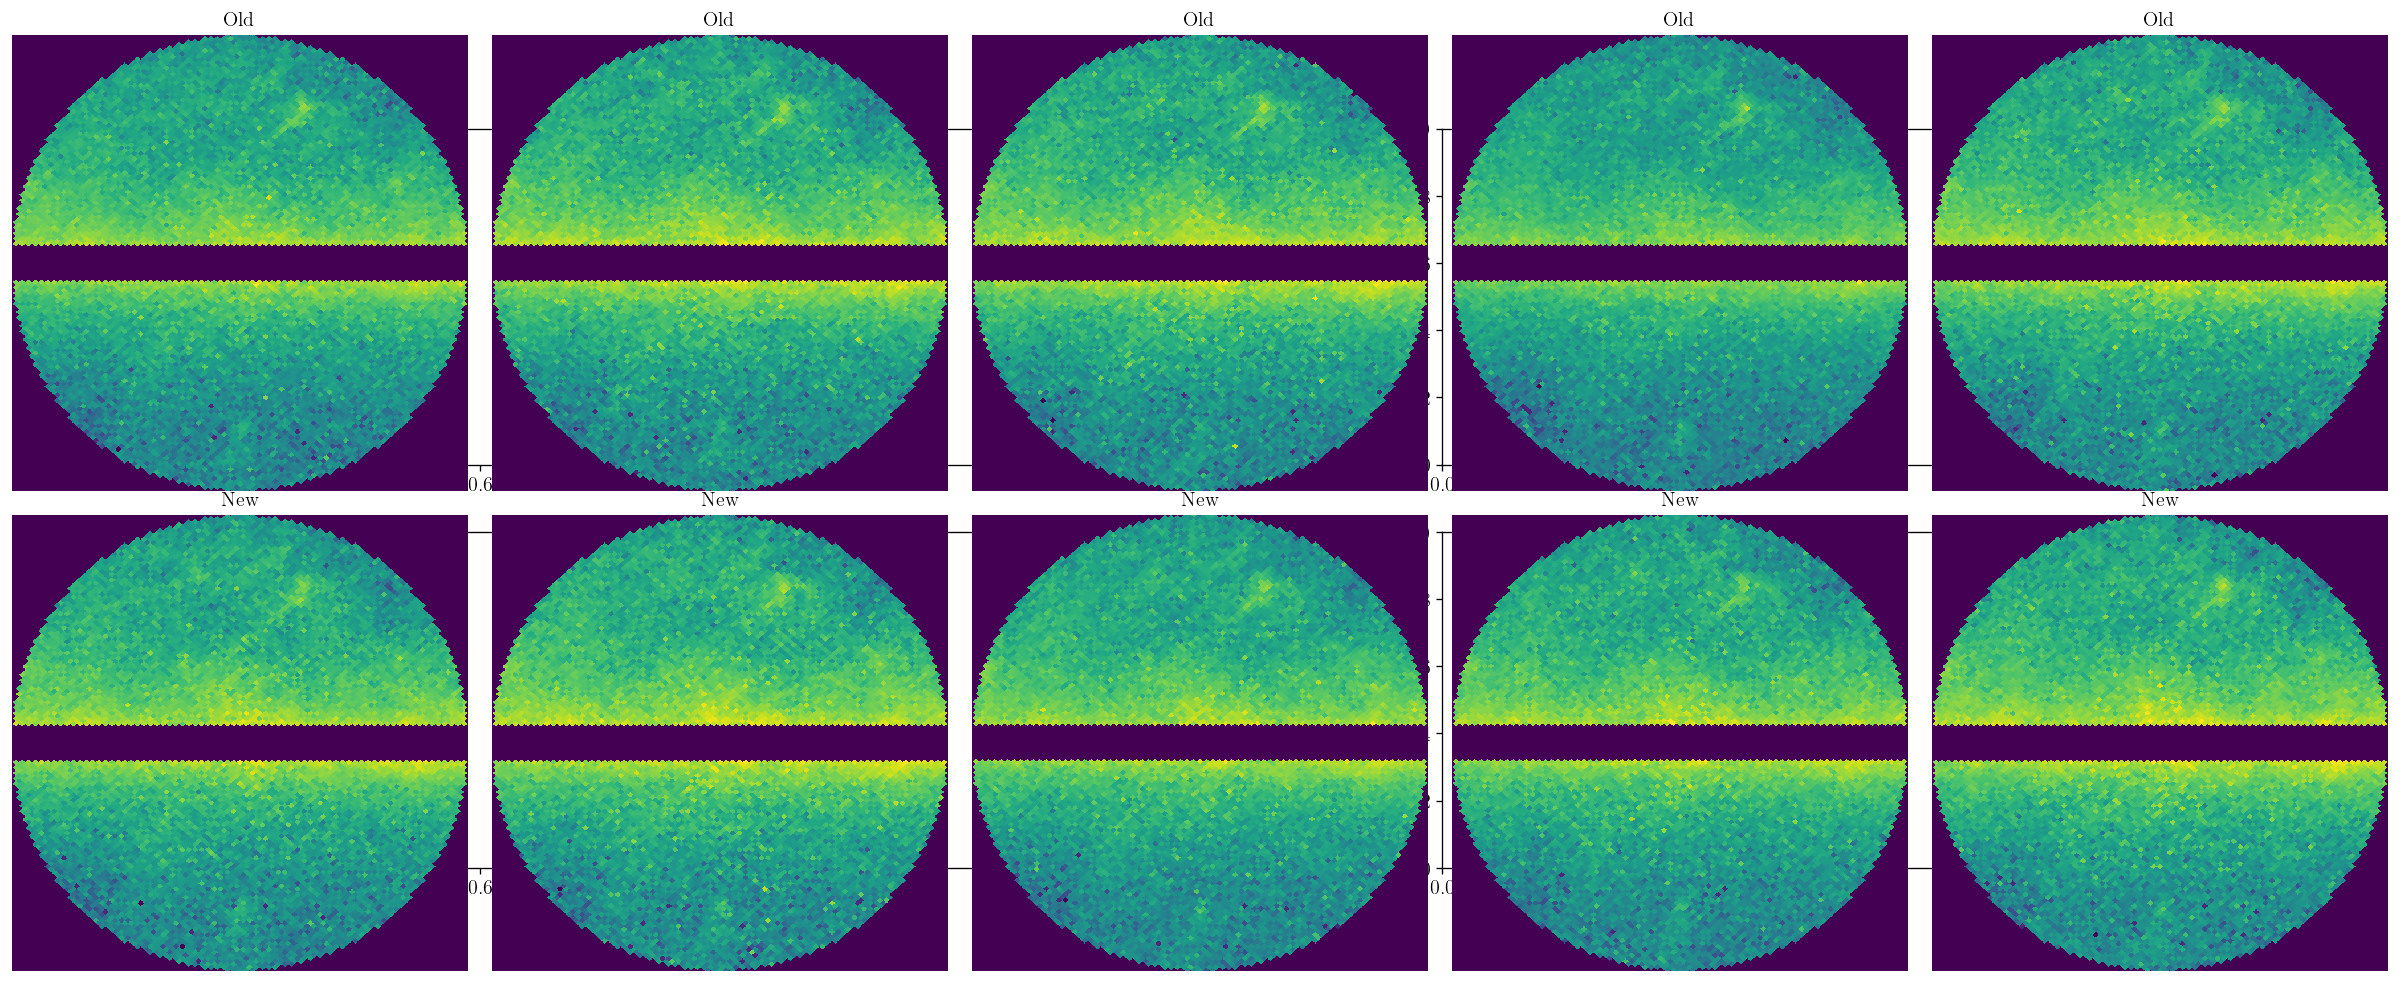

In [12]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i in range(5):
    dfull = np.zeros(hp.nside2npix(128))
    dfull[~mn] = d_old[i]
    dfull = np.clip(dfull, 0.5, None)
    hp.cartview(dfull, title="Old", sub=(2, 5, i+1), fig=fig, cbar=False, lonra=[-25, 25], latra=[-25, 25], norm='log')
    dfull = np.zeros(hp.nside2npix(128))
    dfull[~mn] = d_new[i]
    dfull = np.clip(dfull, 0.5, None)
    hp.cartview(dfull, title="New", sub=(2, 5, i+6), fig=fig, cbar=False, lonra=[-25, 25], latra=[-25, 25], norm='log')

In [29]:
d = np.load("../outputs/simulations/sim_gc17_deltapsf_n100.npy")
mn = np.load("mask_norm.npy")
mr = np.load("mask_roi.npy")

In [30]:
dfull = np.zeros(hp.nside2npix(128))
dfull[~mn] = d[0]
np.mean(dfull[~mr])

0.8755666033045767

In [31]:
dfull = np.zeros((100, hp.nside2npix(128)))
dfull[:, ~mn] = d
np.mean(dfull[:,~mr])

0.8557552273724228

In [32]:
np.sum(~mr) / np.sum(~mn)

0.8247708634828751

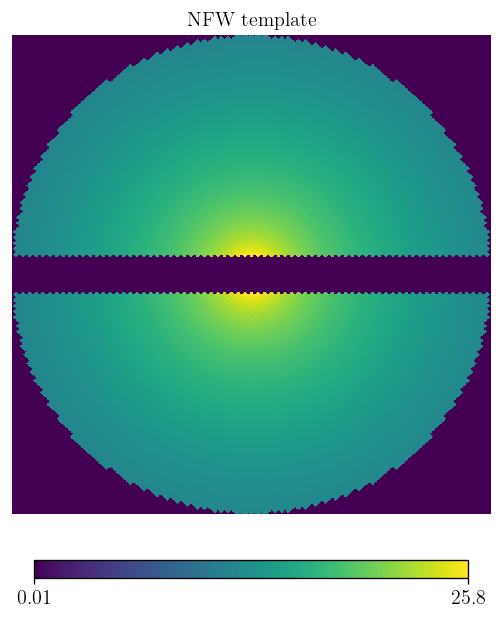

In [33]:
a = np.load("../data/fermi_data_573w/fermi_data_128/template_nfw_g1p2.npy")
b = a.copy()
b[mn] = 0.01
hp.cartview(b, lonra=[-25, 25], latra=[-25, 25], norm='log', title='NFW template')

In [13]:
np.mean(a[~mr]) / np.mean(a[~mn])

0.852570116561151

In [34]:
dfull = np.zeros(hp.nside2npix(128))
dfull[~mn] = d[0]

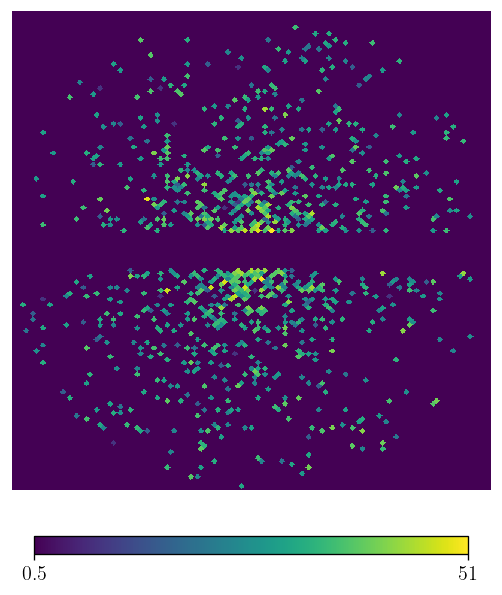

In [35]:
hp.cartview(np.clip(dfull, 0.5, None), lonra=[-25, 25], latra=[-25, 25], title='', norm='log')